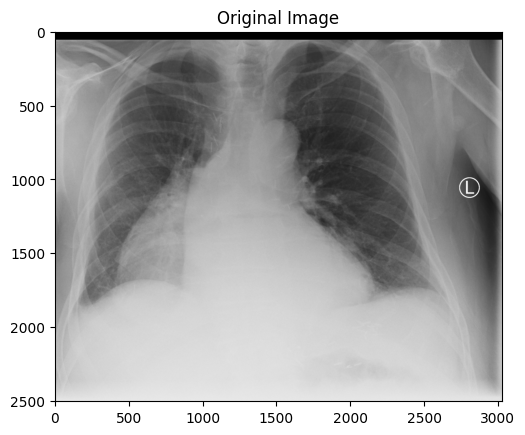

In [15]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import correlate, convolve, median_filter

image = cv2.imread(r'D:\MSAIM\trimister-3 msaiml\Computer_vision\Computer_vision_practical\CIA-2\img\Program-1.jpeg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.show()

In [16]:
# Defining three different masks for correlation
mask1 = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)  # Vertical edge detection
mask2 = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)  # Horizontal edge detection
mask3 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32) 
mask4 = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32) 
#  for sharpining and smoohening
mask5 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32) 
mask6 = np.ones((3, 3), dtype=np.float32) / 9



In [17]:
#  define correlation and convolution function
def correlation(image, kernel):
    return correlate(image, kernel, mode='constant', cval=0.0)

def convolution(image, kernel):
    flipped_kernel = np.flipud(np.fliplr(kernel))
    return convolve(image, flipped_kernel, mode='constant', cval=0.0)


In [18]:
# Apply correlation with the defined masks
correlated_image1 = correlation(image, mask1)
correlated_image2 = correlation(image, mask2)
correlated_image3 = correlation(image, mask3)
correlated_image4 = correlation(image, mask4)
correlated_image5 = correlation(image, mask5)


In [19]:
# Apply convolution with the defined masks
convolution_image1 = convolution(image, mask1)
convolution_image2 = convolution(image, mask2)
convolution_image3 = convolution(image, mask3)
convolution_image4 = convolution(image, mask4)
convolution_image5 = convolution(image, mask5)

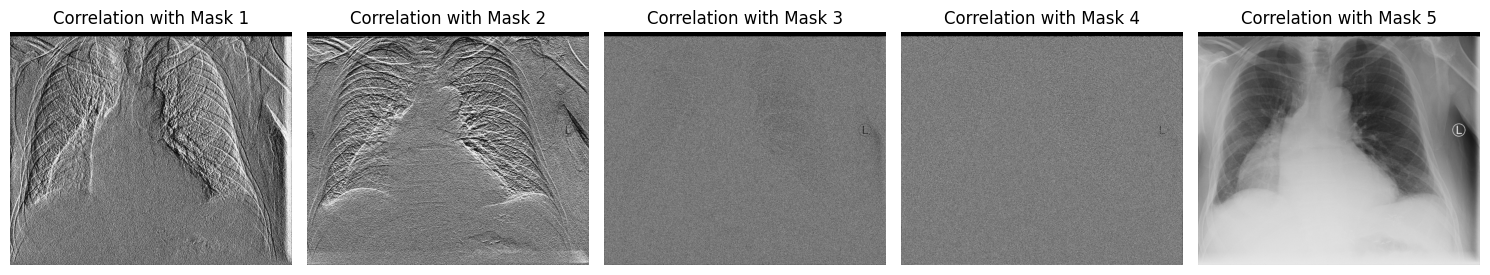

In [20]:



# Display the results
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
axes[0].imshow(correlated_image1, cmap='gray')
axes[0].set_title('Correlation with Mask 1')
axes[0].axis('off')

axes[1].imshow(correlated_image2, cmap='gray')
axes[1].set_title('Correlation with Mask 2')
axes[1].axis('off')

axes[2].imshow(correlated_image3, cmap='gray')
axes[2].set_title('Correlation with Mask 3')
axes[2].axis('off')

axes[3].imshow(correlated_image4, cmap='gray')
axes[3].set_title('Correlation with Mask 4')
axes[3].axis('off')

axes[4].imshow(correlated_image5, cmap='gray')
axes[4].set_title('Correlation with Mask 5')
axes[4].axis('off')



plt.tight_layout()
plt.show()

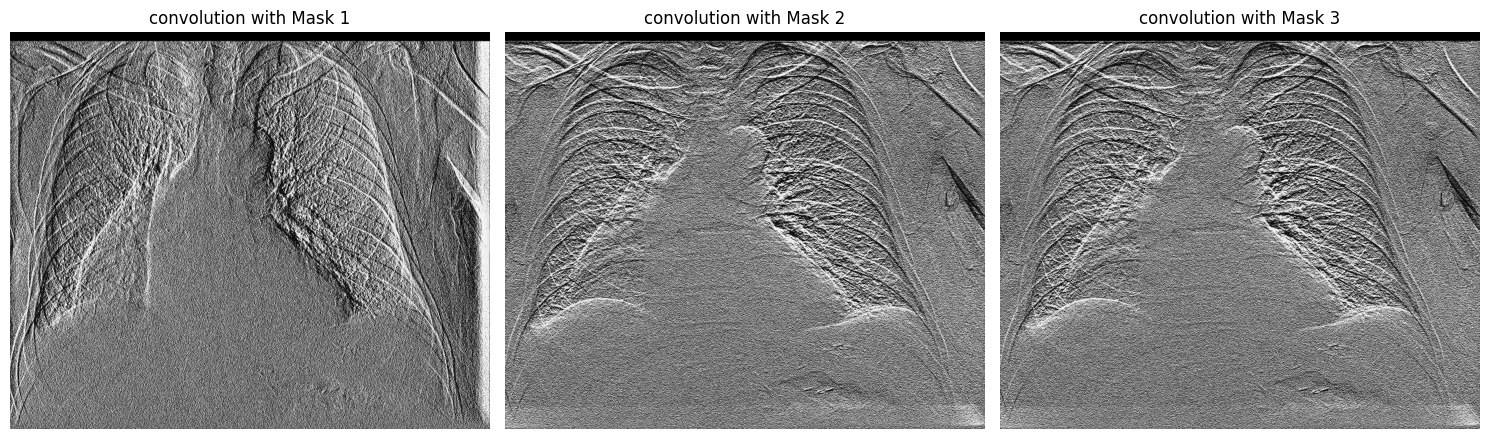

In [21]:

# Display the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(convolution_image1, cmap='gray')
axes[0].set_title('convolution with Mask 1')
axes[0].axis('off')

axes[1].imshow(convolution_image2, cmap='gray')
axes[1].set_title('convolution with Mask 2')
axes[1].axis('off')

axes[2].imshow(convolution_image2, cmap='gray')
axes[2].set_title('convolution with Mask 3')
axes[2].axis('off')

plt.tight_layout()
plt.show()

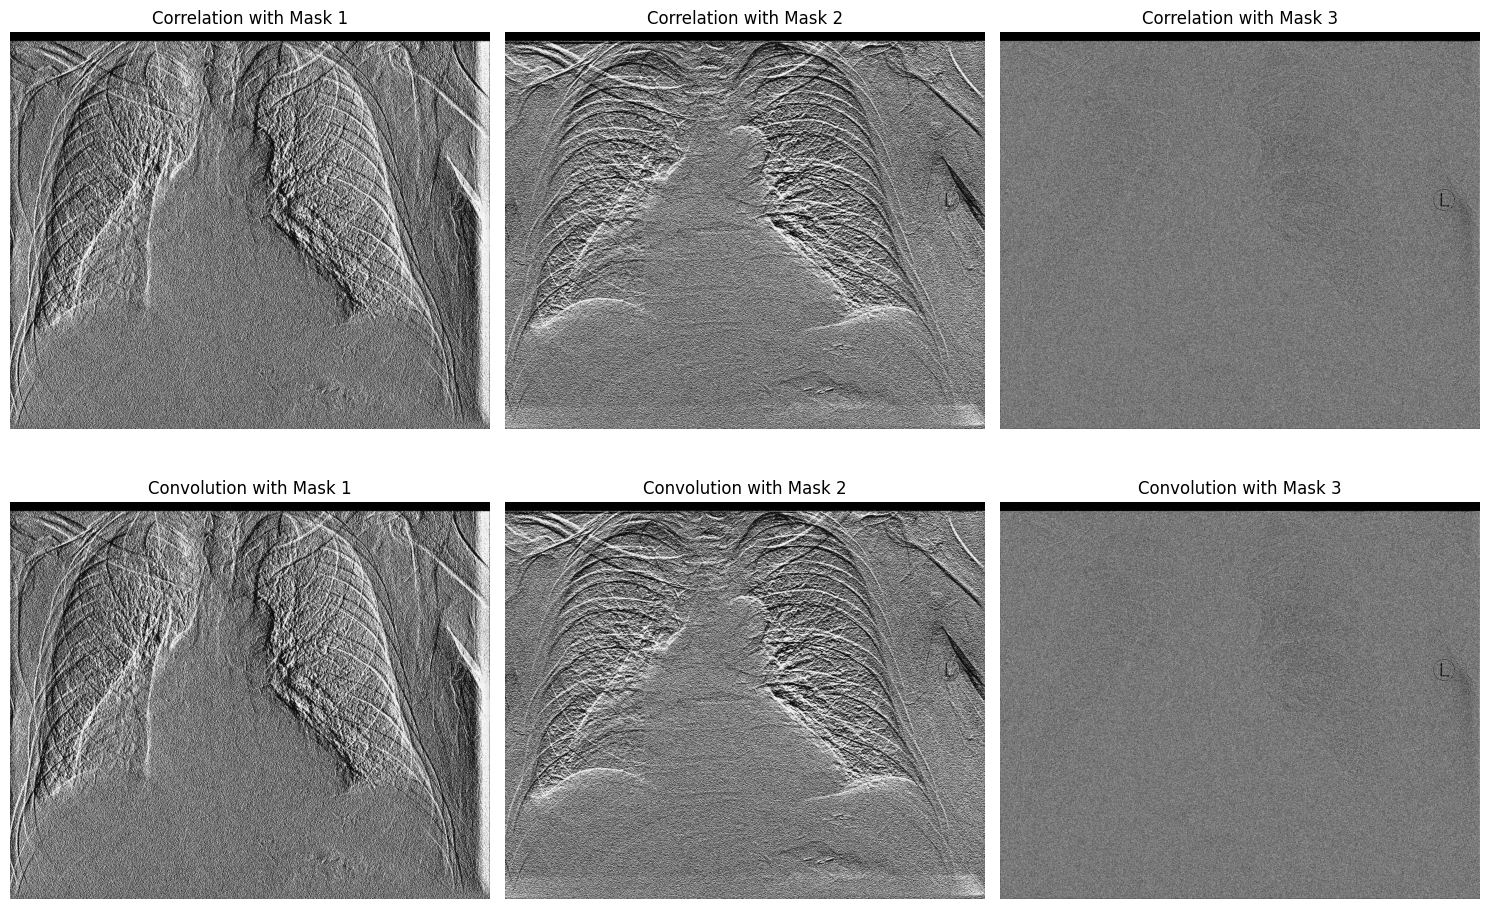

In [22]:
# Display the combined results of correlation and convolution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Correlation results
axes[0, 0].imshow(correlated_image1, cmap='gray')
axes[0, 0].set_title('Correlation with Mask 1')
axes[0, 0].axis('off')

axes[0, 1].imshow(correlated_image2, cmap='gray')
axes[0, 1].set_title('Correlation with Mask 2')
axes[0, 1].axis('off')

axes[0, 2].imshow(correlated_image3, cmap='gray')
axes[0, 2].set_title('Correlation with Mask 3')
axes[0, 2].axis('off')

# Convolution results
axes[1, 0].imshow(convolution_image1, cmap='gray')
axes[1, 0].set_title('Convolution with Mask 1')
axes[1, 0].axis('off')

axes[1, 1].imshow(convolution_image2, cmap='gray')
axes[1, 1].set_title('Convolution with Mask 2')
axes[1, 1].axis('off')

axes[1, 2].imshow(convolution_image3, cmap='gray')
axes[1, 2].set_title('Convolution with Mask 3')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [23]:



"""
3 . Correlation vs. Convolution in Template Matching
Correlation applies the mask directly to the image, preserving spatial alignment.
Convolution flips the mask, which changes the feature detection behavior.
Correlation is preferred in pattern matching because it keeps the template unchanged.

4 . Improving Detection Accuracy
Increase kernel size for more detailed feature extraction.
Use higher-order derivative filters for enhanced edge detection.
Normalize image intensity to maintain contrast.
Apply thresholding and non-maximum suppression.

5 . Choosing Between Correlation and Convolution in Medical Imaging
Use correlation for pattern/template matching (e.g., detecting tumors).
Use convolution for edge detection (e.g., identifying bone structures).
Combining both can improve medical image analysis, enhancing contrast and detail.
"""


'\n3 . Correlation vs. Convolution in Template Matching\nCorrelation applies the mask directly to the image, preserving spatial alignment.\nConvolution flips the mask, which changes the feature detection behavior.\nCorrelation is preferred in pattern matching because it keeps the template unchanged.\n\n4 . Improving Detection Accuracy\nIncrease kernel size for more detailed feature extraction.\nUse higher-order derivative filters for enhanced edge detection.\nNormalize image intensity to maintain contrast.\nApply thresholding and non-maximum suppression.\n\n5 . Choosing Between Correlation and Convolution in Medical Imaging\nUse correlation for pattern/template matching (e.g., detecting tumors).\nUse convolution for edge detection (e.g., identifying bone structures).\nCombining both can improve medical image analysis, enhancing contrast and detail.\n'

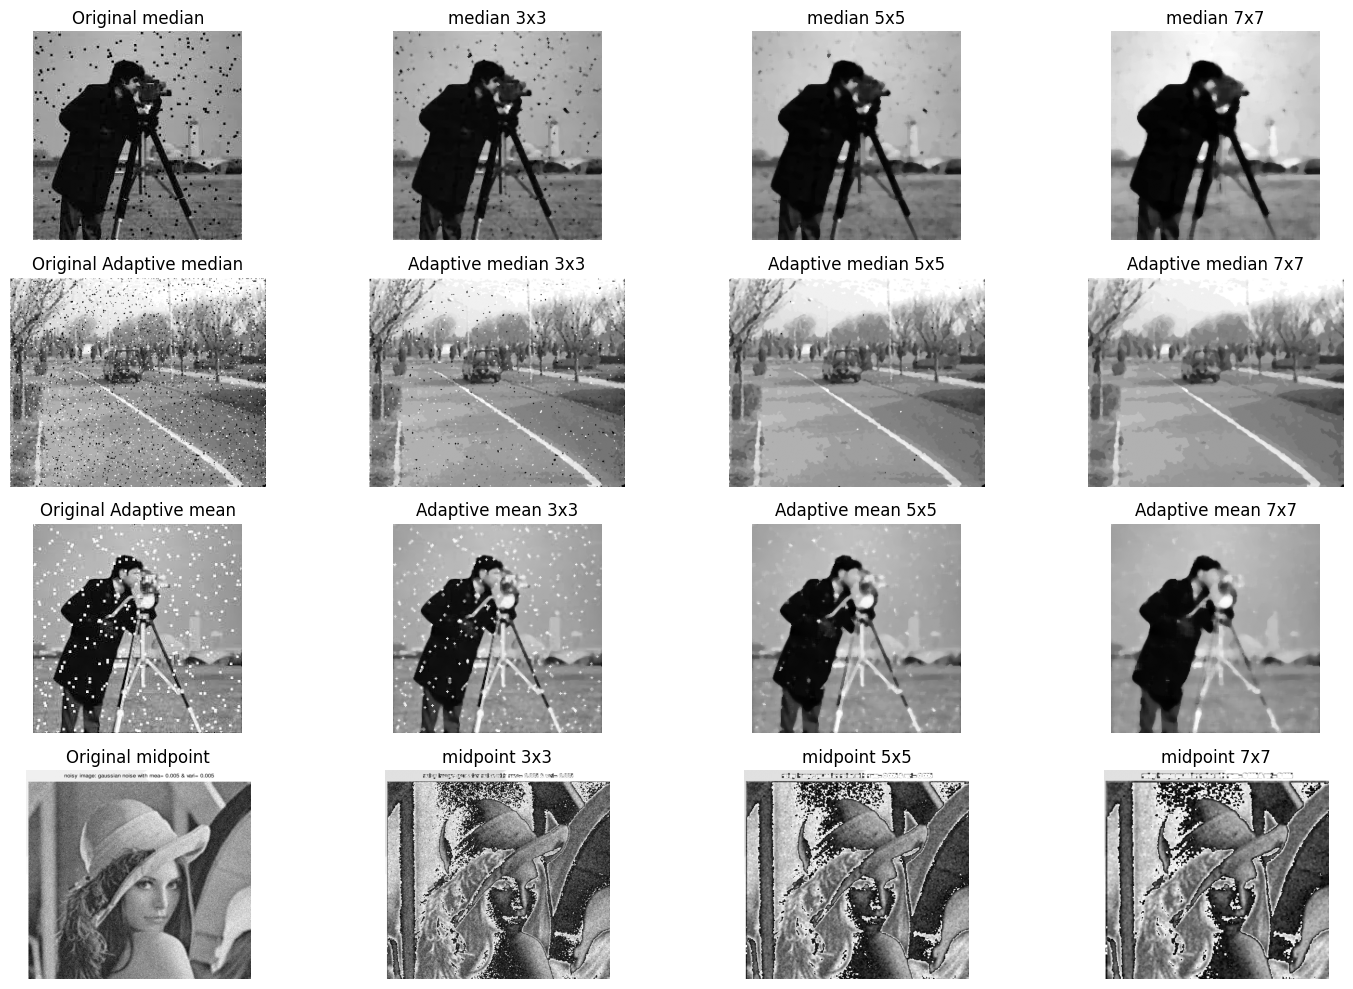

In [24]:
# program 2
import cv2
import numpy as np
from scipy.ndimage import median_filter

def apply_median_filter(image, kernel_size):
    return median_filter(image, size=kernel_size)

def min_filter(image, kernel_size):
    return cv2.erode(image, np.ones((kernel_size, kernel_size), np.uint8))

def midpoint_filter(image, kernel_size):
    max_filter = cv2.dilate(image, np.ones((kernel_size, kernel_size), np.uint8))
    min_filter = cv2.erode(image, np.ones((kernel_size, kernel_size), np.uint8))
    return (max_filter + min_filter) // 2

# Load grayscale vehicle image
image_pepper = cv2.imread(r"D:\MSAIM\trimister-3 msaiml\Computer_vision\Computer_vision_practical\CIA-2\img\pepper.png", cv2.IMREAD_GRAYSCALE)
image_salt = cv2.imread(r"D:\MSAIM\trimister-3 msaiml\Computer_vision\Computer_vision_practical\CIA-2\img\salt.png", cv2.IMREAD_GRAYSCALE)
image_salt_pepper = cv2.imread(r"D:\MSAIM\trimister-3 msaiml\Computer_vision\Computer_vision_practical\CIA-2\img\saltandpepper.png", cv2.IMREAD_GRAYSCALE)
image_gausian = cv2.imread(r"D:\MSAIM\trimister-3 msaiml\Computer_vision\Computer_vision_practical\CIA-2\img\gausian.png", cv2.IMREAD_GRAYSCALE)

# Apply filters with different kernel sizes
kernel_sizes = [3, 5, 7]

filtered_images = {
    "median": {size: apply_median_filter(image_pepper, size) for size in kernel_sizes},
    "Adaptive median": {size: apply_median_filter(image_salt_pepper, size) for size in kernel_sizes},
    "Adaptive mean": {size: cv2.medianBlur(image_salt, size) for size in kernel_sizes},
    "midpoint": {size: midpoint_filter(image_gausian, size) for size in kernel_sizes},
}

# Display results


fig, axes = plt.subplots(nrows=len(filtered_images), ncols=len(kernel_sizes) + 1, figsize=(15, 10))

for i, (filter_type, results) in enumerate(filtered_images.items()):
    # Display the original image in the first column
    if filter_type == "median":
        original_image = image_pepper
    elif filter_type == "Adaptive median":
        original_image = image_salt_pepper
    elif filter_type == "Adaptive mean":
        original_image = image_salt
    elif filter_type == "midpoint":
        original_image = image_gausian

    axes[i, 0].imshow(original_image, cmap='gray')
    axes[i, 0].set_title(f"Original {filter_type}")
    axes[i, 0].axis('off')

    # Display the filtered images in the subsequent columns
    for j, (size, img) in enumerate(results.items()):
        axes[i, j + 1].imshow(img, cmap='gray')
        axes[i, j + 1].set_title(f"{filter_type} {size}x{size}")
        axes[i, j + 1].axis('off')

plt.tight_layout()
plt.show()


